In [1]:
"""
exploration: 
  a robot is somewhere on a line, its position is the state 'x'.

  there's a prior p(x), a belief about position before measuring. make it a gaussian centered at 0, with some standard deviation 's_location' (indicating that the position is first believed to be about at 0 with some uncertainty of 's_location')

  theres also a sensor model (likelihood) p(y | x). which gives the probability of a sensor reading 'y' given a true position 'x'. the sensor should return a position corrupted by gaussian noise. p(y | x) is a gaussian in x, centered at the measurement y, with the sensor's noise standard deviation of 's_sensor'. so if the sensor reads y = 2, the likelihood is a gaussian bump centered at x = 2

  task: say a measurement 'y' comes in (lets say 2). compute the posterior p(x | y) using Bayes' rule.
"""

%run -i ../1.definitions/explore.ipynb

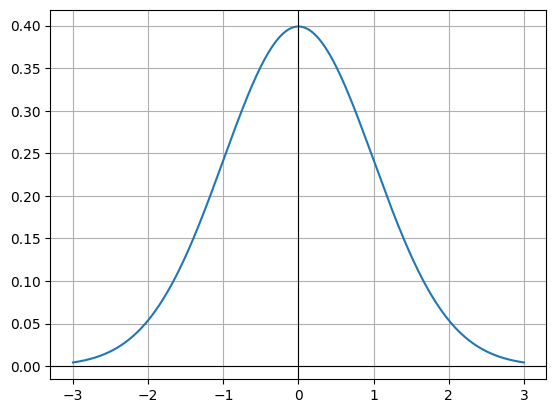

1.0


In [2]:
if __name__ == '__main__' and '__file__' not in globals():
  std_normal_dist = _make_gaussian(mean = 0.0, stdev = 1.0)
  _plot_function(std_normal_dist, -3, 3)
  print(_simpson_integrate(std_normal_dist))

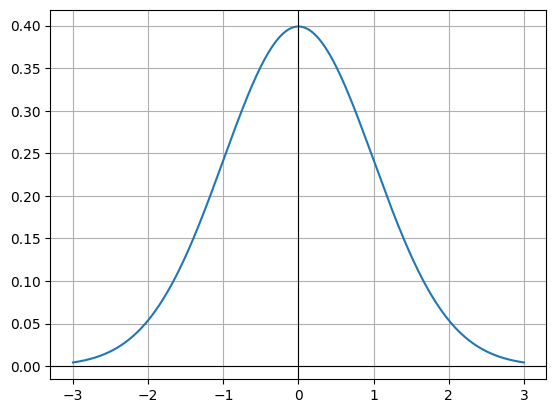

In [3]:
if __name__ == '__main__' and '__file__' not in globals():
  location = _make_gaussian(0, 1)
  _plot_function(location, -3, 3)

In [4]:
def _sensor_likelihood(y, x):
  f = _make_gaussian(x, 1.0)
  return f(y)

In [5]:
def _true_loc_likelihood(x, y):
  def numerator(_x):
    return _sensor_likelihood(y, _x) * location(_x)
  evidence = _simpson_integrate(numerator)
  return numerator(x) / evidence

In [6]:
def _posterior(x):
  return _true_loc_likelihood(x, 2.0)

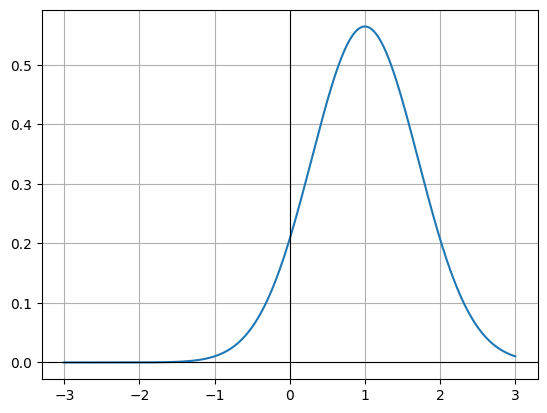

In [7]:
if __name__ == '__main__' and '__file__' not in globals():
  _plot_function(_posterior, -3, 3)